# testSCVIbatch.ipynb — cross-batch pair-MSE alignment loss

Inherits from `testRUVVAE_ZINB.ipynb` (uses the same TH subset + scVI-style
data prep). Calls [`model_scvi_batch_pair.SCVIWithBatchPairLoss`](model_scvi_batch_pair.py)
which adds an extra cross-batch MSE term to the standard scVI loss.

Pipeline:
1. Load data & prepare scVI format (counts in X, n_genes_on covariate)
2. `setup_anndata` + build `SCVIWithBatchPairLoss`
3. Forward validation: `pair_loss > 0` only when mini-batch has ≥ 2 batches
4. Train (100 epochs), watch `batch_pair_mse`
5. Evaluate alignment: iLISI / ASW vs baseline SCVI
6. Visualise: UMAP by batch, per-pair MSE convergence, latent `z` distribution

In [1]:
from scipy.sparse import csr_matrix, issparse
import numpy as np
import scanpy as sc


In [2]:
# ========== Load the same data subset as testRUVVAE_ZINB.ipynb ==========

adata = sc.read_h5ad(
    "/data3/junyi/scvi/AMY_scVImodel.h5ad"
)

# adata_subset = adata[
#     adata.obs["celltype.L2"].isin(
#         adata.obs["celltype.L2"].value_counts().head(2).index[1:2]
#     )
# ]
# adata_subset = adata_subset[adata_subset.obs["sex"] == "M"]

print(f"adata_subset shape: {adata.shape}")
print(f"status counts:\n{adata.obs['status'].value_counts()}")
print(f"company counts:\n{adata.obs['company'].value_counts()}")

adata_subset shape: (247304, 16428)
status counts:
status
CUSUS    76001
CON      72106
CSRES    37968
CURES    36809
CSSUS    24420
Name: count, dtype: int64
company counts:
company
yunzhun     118081
beirui      114477
seekgene     14746
Name: count, dtype: int64


In [3]:
adata.layers

Layers with keys: 'count_diff', 'counts', 'scvi_nrom_counts', 'scvi_reconstructed_counts', None

In [4]:
hkg_priority = [
    "Aars", "Sars",
    "Polr2a", "Polr2f",
    "Psmd6", "Psmd7", "Psma5",
    "Rer1", "Ipo8", "Pop4", "Pes1",
    "Oaz1",
    "Rpl13a", "Rpl27", "Rps13", "Rps20",
    "Hprt1", "Gusb", "Ppia", "Ywhaz",
]

candidate_negative_control_genes = [
    "Oaz1", "Rps13", "Rps20", "Rpl27",
    "Aars", "Polr2f", "Psmd6", "Psmd7", "Psma5",
    "Ipo8", "Pop4", "Pes1", "Rer1",
    "Rpl13a", "Cyc1", "Sdha", "Ubc",
]

hkg_priority = candidate_negative_control_genes + hkg_priority


In [5]:
sc.pp.normalize_total(adata, target_sum=1e4)

/home/junyichen/anaconda3/envs/scvi-env/lib/python3.12/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


In [6]:
adata.layers["scvi_nrom_counts"] = adata.layers["scvi_nrom_counts"] * 1e4

In [20]:
adata.layers["scvi_nrom_counts"].min()

np.float32(9.3125425e-05)

In [27]:
adata.layers["scvi_norm"] =  adata.layers["scvi_nrom_counts"].copy()


In [28]:
mask = (adata.layers['scvi_reconstructed_counts'] == 0)

In [29]:
adata.layers["scvi_norm"][mask] = 0

In [30]:
adata.layers["scvi_norm"].min()

np.float32(0.0)

In [31]:

def to_sparse_int(arr, dtype=np.float32):
    """把 numpy / float / 稀疏数组转换成 (n_cells, n_genes) 的 csr int 矩阵。

    - 输入若为稀疏矩阵：保持格式，只把 dtype 转成 int32。
    - 输入若为稠密 ndarray：rint 截断后构造 csr（counts 必须是离散整数）。
    - 用于把 decoder 抽样得到的 counts 写入 adata.layers["..."]，避免 h5ad
      把 float 数组按 ~8 字节/元素存储（counts 通常很稀疏 + 数值小）。
    """
    if issparse(arr):
        return csr_matrix(arr).astype(dtype)
    arr = np.asarray(arr)
    if arr.ndim == 1:
        # 防御性：误传 1D 时强制 reshape 成单行矩阵
        arr = arr.reshape(1, -1)
    if dtype == np.int32: 
        return csr_matrix(np.rint(arr).astype(dtype))
    else:
        return csr_matrix(arr.astype(dtype))


In [32]:
layer_val = to_sparse_int(adata.layers["scvi_norm"], dtype=np.float32)
layer_val.eliminate_zeros()
adata.layers["scvi_norm"] = layer_val

In [49]:
globalmax = max(np.log(adata.layers["scvi_norm"].max()), np.log(adata.X.max()))


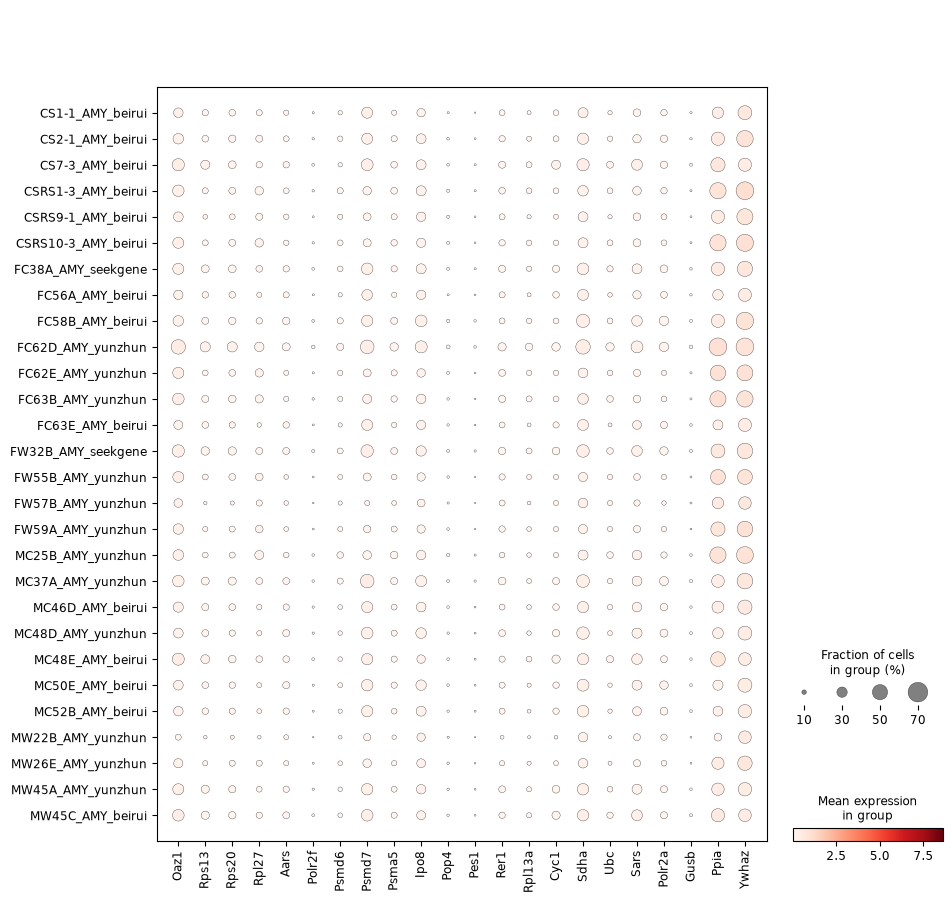

In [50]:
seen = set()
hkg_genes = []
for g in hkg_priority:
    if g in adata.var_names and g not in seen:
        seen.add(g)
        hkg_genes.append(g)

fig = sc.pl.dotplot(
    adata,
    var_names=hkg_genes,
    groupby="sample",
    layer="scvi_norm",
    swap_axes=False,
    vmax=globalmax,
    dendrogram=False,
    return_fig=True,
)
fig.show()


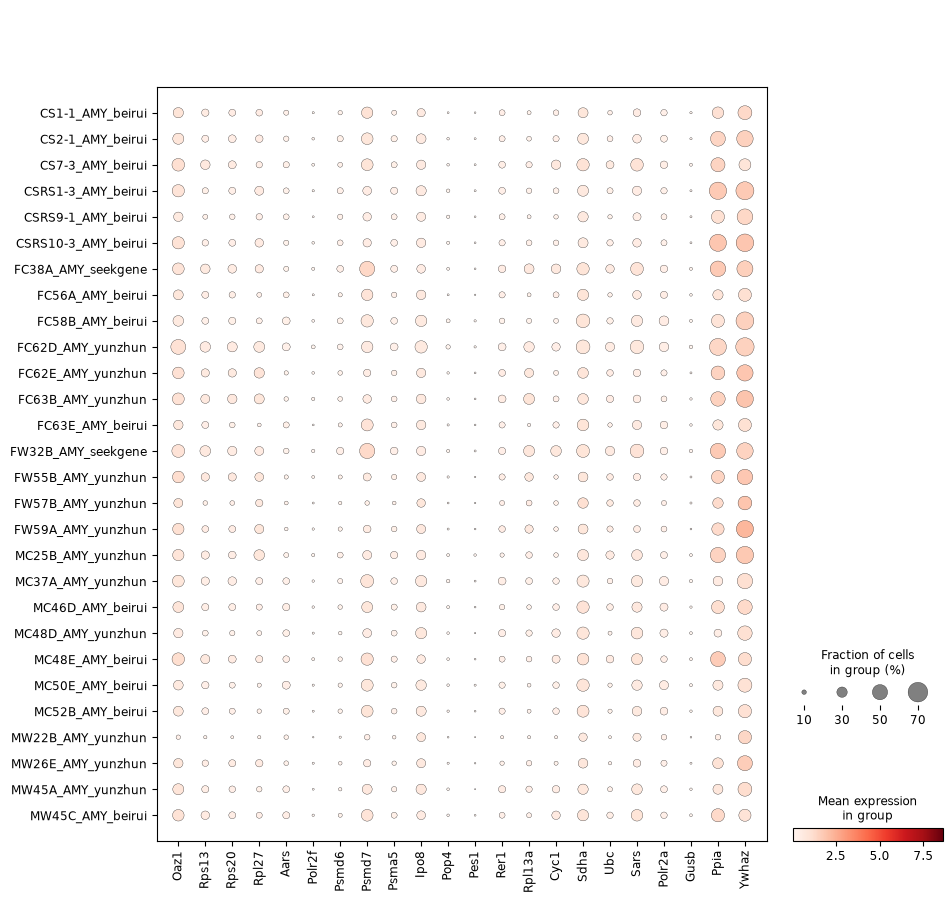

In [51]:

fig = sc.pl.dotplot(
    adata,
    var_names=hkg_genes,
    groupby="sample",
    swap_axes=False,
    vmax=globalmax,
    dendrogram=False,
    return_fig=True,
)
fig.show()


In [37]:
# print the max,min,mean value of the normalized in batchpair_D1_normlized 
# print the max, min, mean value of the normalized data in adata.X
print(f"Max value in adata.X: {adata.X.max()}")
print(f"Min value in adata.X: {adata.X.min()}")
print(f"Mean value in adata.X: {adata.X.mean()}")


Max value in adata.X: 5421.5185546875
Min value in adata.X: 0.0
Mean value in adata.X: 0.6087167859077454


In [41]:
# print the max, min, mean value of the normalized data in adata.X
print(f"Max value in adata.X: {adata.layers['scvi_norm'].max()}")
print(f"Min value in adata.X: {adata.layers['scvi_norm'].min()}")
print(f"Mean value in adata.X: {adata.layers['scvi_norm'].mean()}")


Max value in adata.X: 3025.378662109375
Min value in adata.X: 0.0
Mean value in adata.X: 0.3678784668445587


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.sparse import issparse

layer_name = "scvi_nrom_counts"
layer = adata.layers[layer_name]
values = (
    layer.toarray().ravel()
    if issparse(layer)
    else np.asarray(layer).ravel()
)
values = values[np.isfinite(values)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(values, bins=100, color="steelblue", alpha=0.85)
axes[0].set_title(f"{layer_name}: raw values")
axes[0].set_xlabel("normalized expression")
axes[0].set_ylabel("frequency")
axes[0].grid(alpha=0.25)

axes[1].hist(np.log1p(values), bins=100, color="darkorange", alpha=0.85)
axes[1].set_title(f"{layer_name}: log1p values")
axes[1].set_xlabel("log1p(normalized expression)")
axes[1].set_ylabel("frequency")
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

print(f"n values: {values.size}")
print(f"min: {values.min():.6g}")
print(f"max: {values.max():.6g}")
print(f"mean: {values.mean():.6g}")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.sparse import issparse

x = adata.X
values = x.toarray().ravel() if issparse(x) else np.asarray(x).ravel()
values = values[np.isfinite(values)]

# Limit plotting memory for very large matrices while keeping a reproducible sample.
rng = np.random.default_rng(42)
max_values = 2_000_000
if values.size > max_values:
    values = rng.choice(values, size=max_values, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(values, bins=100, color="seagreen", alpha=0.85)
axes[0].set_title("adata.X: normalized expression")
axes[0].set_xlabel("expression value")
axes[0].set_ylabel("frequency")
axes[0].grid(alpha=0.25)

axes[1].hist(np.log1p(values), bins=100, color="mediumpurple", alpha=0.85)
axes[1].set_title("adata.X: log1p expression")
axes[1].set_xlabel("log1p(expression value)")
axes[1].set_ylabel("frequency")
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

print(f"values plotted: {values.size}")
print(f"min: {values.min():.6g}")
print(f"max: {values.max():.6g}")
print(f"mean: {values.mean():.6g}")

In [ ]:
sc.tl.rank_genes_groups(adata, groupby="company", method="wilcoxon", n_genes=adata.shape[1])